# Data Preprocessing and Quality Control
Dataset from: https://www.kaggle.com/datasets/tranduongminhdai/smartbug-dataset/data

In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
# Run once:
#import os
## Change this to the folder in your Drive where you saved kaggle.json

#os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/MyDrive/Kaggle"
#!mkdir -p "/content/drive/My Drive/CPSC440_project/data/smartbug_data"

## Download dataset to drive
#!kaggle datasets download -d tranduongminhdai/smartbug-dataset -p "/content/drive/My Drive/CPSC440_project/data/smartbug_data" --unzip

In [68]:
import pandas as pd

csv_path = "/content/drive/My Drive/CPSC440_project/data/smartbug_data/smartbugs_final_ver.csv"
df = pd.read_csv(csv_path)

In [69]:
df

,Unnamed: 0,address,tools,lines,nb_vulnerabilities,source_code,labels
0,0,0x8d12a197cb00d4747a1fe03395095ce2a5cc6819,"{'mythril': {'vulnerabilities': {}, 'categorie...","[32, 229, 38, 136, 268, 45, 51, 254, 56, 28, 2...",15.0,pragma solidity ^0.4.9;\n\ncontract SafeMath {...,unknow
1,1,0x2a0c0dbecc7e4d658f48e01e3fa353f44050c208,{'mythril': {'vulnerabilities': {'Unchecked CA...,"[163, 36, 101, 133, 110, 145, 122, 127]",10.0,pragma solidity ^0.4.16;\n\ncontract Token {\n...,reentrancy
2,2,0x174bfa6600bf90c885c7c01c7031389ed1461ab9,"{'mythril': {'vulnerabilities': {}, 'categorie...",[],0.0,pragma solidity >=0.4.22 <0.6.0;\n\ncontract o...,clean
3,3,0x06012c8cf97bead5deae237070f9587f8e7a266d,{'mythril': {'vulnerabilities': {'Unchecked CA...,"[769, 1414, 1287, 1686, 1175, 1048, 1817, 924,...",82.0,pragma solidity ^0.4.11;\n\n\n/**\n * @title O...,arithmetic
4,4,0x86fa049857e0209aa7d9e616f7eb3b3b78ecfdb0,"{'mythril': {'vulnerabilities': {}, 'categorie...",[115],1.0,contract DSNote {\n event LogNote(\n ...,arithmetic
...,...,...,...,...,...,...,...
47326,47446,0x000000eade0fe9269d0412a6055b6f3c5d968488,{'mythril': {'vulnerabilities': {'Message call...,"[47, 49, 51, 52, 54, 56]",6.0,pragma solidity ^0.4.23;\n\n// File: contracts...,reentrancy
47327,47447,0x000000d4e883e304c7f9574ebeecf238eb55a40f,"{'mythril': {'vulnerabilities': {}, 'categorie...",[24],1.0,pragma solidity ^0.4.24;\n\ninterface TokenRec...,arithmetic
47328,47448,0x000000961d1ac83a67d0ce61612b36f18c10c9b7,"{'mythril': {'vulnerabilities': {}, 'categorie...",[26],1.0,pragma solidity ^0.4.24;\n\ninterface TokenRec...,arithmetic
47329,47449,0x00000000e82eb0431756271f0d00cfb143685e7b,"{'mythril': {'vulnerabilities': {}, 'categorie...","[4069, 4029]",2.0,pragma solidity 0.5.6;\n\n\n/**\n * @title Met...,access_control


In [70]:
df.shape

(47331, 7)

In [71]:
df["labels"].value_counts()

,count
labels,
arithmetic,26645
reentrancy,5225
unknow,4508
front_running,3251
denial_service,2875
clean,2742
unchecked_low_calls,1131
access_control,591
time_manipulation,363


In [72]:
shortest_contract_index = df['source_code'].apply(len).idxmin()
shortest_contract = df.loc[shortest_contract_index]
shortest_contract['source_code']
shortest_contract

,43569
Unnamed: 0,43674
address,0x7222af88c86620651a5594204d1f5305b1a5671f
tools,"{'mythril': {'vulnerabilities': {}, 'categorie..."
lines,[]
nb_vulnerabilities,0.0
source_code,contract Eater{\n\tfunction(){\n\t\t\n\t}\n}
labels,clean


In [73]:
df["is_vulnerable"] = df['nb_vulnerabilities'] > 0

In [74]:
df["is_vulnerable"].value_counts()

,count
is_vulnerable,
True,44589
False,2742


Because there is a serious class imbalance between the vulnerable vs safe smart contracts, we chose to downsample the vulenrable contracts through stratified sampling to 12K samples.

In [75]:
df_vulnerable = df[df['is_vulnerable'] == True]
df_safe = df[df['is_vulnerable'] == False]

target_vuln_size = 12_000
df_vulnerable_sampled = df_vulnerable.groupby('labels', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), int(target_vuln_size * (len(x)/len(df_vulnerable)))), random_state=32)
)

# Combine back with all your clean samples
df_final_train = pd.concat([df_vulnerable_sampled, df_safe]).sample(frac=1, random_state=32).reset_index(drop=True)

/tmp/ipykernel_16490/3008011757.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_vulnerable_sampled = df_vulnerable.groupby('labels', group_keys=False).apply(


In [76]:
# get rid of the ambiguous vulnerability smart contracts:
df_clean = df_final_train[df_final_train['labels'] != 'unknow'].copy()
challenge_eval_df = df_final_train[df_final_train['labels'] == 'unknow'].copy()

In [77]:
print(df_clean.shape)
print(challenge_eval_df.shape)

(13525, 8)
(1213, 8)


In [78]:
df_clean["labels"].value_counts()

,count
labels,
arithmetic,7170
clean,2742
reentrancy,1406
front_running,874
denial_service,773
unchecked_low_calls,304
access_control,159
time_manipulation,97


/tmp/ipykernel_16490/3738891875.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


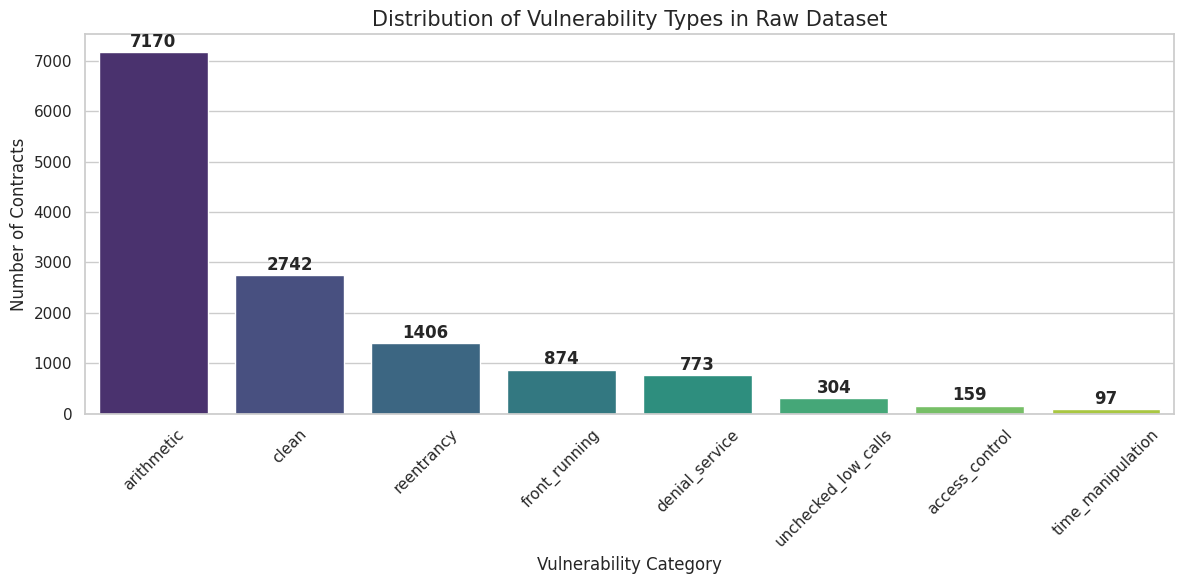

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for academic report
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Use the value counts from your df_clean
label_counts = df_clean['labels'].value_counts()

sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")

plt.title('Distribution of Vulnerability Types in Raw Dataset', fontsize=15)
plt.xlabel('Vulnerability Category', fontsize=12)
plt.ylabel('Number of Contracts', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on top of bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300)
plt.show()

In [80]:
df_clean['labels'].isnull().sum()

np.int64(0)

In [81]:
import re
# Keywords and known non-user-defined functions of Solidity
keywords = frozenset({
    # Solidity Data Types
    'bool', 'int', 'uint', 'string', 'bytes', 'enum', 'struct', 'mapping', 'bytes4', 'bytes32',

    # Keywords
    'pragma', 'solidity', 'contract', 'library', 'interface', 'function', 'modifier', 'event',
    'if', 'else', 'while', 'for', 'do', 'break', 'continue', 'return',
    'import', 'using', 'as', 'assembly', 'emit', 'throw', 'revert', 'assert', 'require',
    'public', 'private', 'internal', 'external', 'view', 'pure', 'payable', 'constant',
    'memory', 'storage', 'calldata', 'immutable', 'override', 'virtual', 'anonymous',

    # Ethereum Specific
    'msg', 'sender', 'value', 'block', 'timestamp', 'gas', 'this', 'super',

    # Solidity Concepts
    'payable', 'constructor', 'indexed', 'case', 'catch', 'const', 'default',
    'float', 'long', 'noReentrancy', 'super', 'or', 'protected', 'noReentrancy',
    'returns', 'event', 'emit', 'export', 'extern', 'false', 'throw', 'true', 'try',
    'union', 'NULL', 'notConfirmed', 'onlyOwner', 'onlyGovernor', 'onlyCommittee',
    'onlyAdmin', 'onlyPlayers', 'ownerExists', 'onlyManager', 'onlyHuman', 'only_owner',
    'onlyCongressMembers', 'preventReentry', 'noEther', 'onlyMembers', 'onlyProxyOwner',
    'confirmed', 'notExecuted', 'assert', 'switch', 'preventReentry',
    'return', 'returns', 'constructor', 'indexed', 'pragma', 'solidity', 'contract', 'library',
    'interface', 'function', 'modifier', 'event', 'if', 'else', 'while', 'for', 'do', 'break',
    'continue', 'return', 'import', 'using', 'as', 'assembly', 'emit', 'throw', 'revert', 'assert',
    'require', 'public', 'private', 'internal', 'external', 'view', 'pure', 'payable', 'constant',
    'memory', 'storage', 'calldata', 'immutable', 'override', 'virtual', 'anonymous',

    # Built-in Functions
    'selfdestruct', 'delegatecall', 'call', 'callcode', 'staticcall', 'create', 'create2',
    'keccak256', 'sha256', 'ripemd160', 'ecrecover', 'addmod', 'mulmod', 'balance', 'extcodesize',
    'extcodecopy', 'codesize', 'codecopy', 'gasleft', 'log0', 'log1', 'log2', 'log3', 'log4',

    # Arithmetic and Logic
    'add', 'sub', 'mul', 'div', 'mod', 'exp', 'iszero', 'lt', 'gt', 'eq', 'ne', 'and', 'or', 'not', 'xor',

    # State Change
    'send', 'transfer', 'approve', 'transferFrom', 'mint', 'burn', 'mintTo', 'burnFrom', 'balanceOf',
    'owner', 'onlyOwner', 'isOwner', 'Transfer', 'Transaction',

    # Other Solidity Identifiers
    'switch', 'pure', 'selfdestruct', 'view', 'this', 'union', 'constant', 'mapping'
})


main_set = frozenset({'function', 'constructor', 'modifier', 'contract'})
main_args = frozenset({'argc', 'argv'})

def remove_version(contract_text):
    return re.sub(r'pragma solidity\s+\^?\d+\.\d+\.\d+;', '', contract_text)

def remove_comments_and_non_ascii(contract):
    contract = re.sub(r'\/\*[\s\S]*?\*\/|\/\/[^\n]*', '', contract)  # Remove comments
    contract = re.sub(r'//.*?\n|/\*.*?\*/', '',contract, flags=re.S)
    contract = re.sub(r'[^\x00-\x7F]+', '', contract)  # Remove non-ASCII characters
    return contract

def remove_blank_lines(contract):
    return '\n'.join(line for line in contract.split('\n') if line.strip())

def clean_solidity_code3(contract):
    contract = remove_version(contract)
    contract = remove_comments_and_non_ascii(contract)
    contract = remove_blank_lines(contract)
    contract = '\n'.join(line.lstrip() for line in contract.splitlines())  # Remove leading spaces

    segments = contract.strip()
    return segments

In [82]:
df_clean = df_clean.rename(columns={"Unnamed: 0": "contract_id"})
df_clean['contract_id']

,contract_id
0,16017
1,21470
3,44054
5,44006
6,26808
...,...
14731,13650
14732,29241
14733,42481
14735,37231


Drop duplicates



In [83]:
df_clean['cleaned_contract'] = df_clean['source_code'].apply(clean_solidity_code3)
df_clean = df_clean.drop_duplicates(subset=['cleaned_contract'])
df_clean = df_clean.reset_index(drop=True)

Determine number of tokens per contract

In [84]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
def get_token_length(code):
    return len(tokenizer.encode(code, truncation=False))

df_clean['token_len'] = df_clean['cleaned_contract'].apply(get_token_length)

Token indices sequence length is longer than the specified maximum sequence length for this model (1221 > 512). Running this sequence through the model will result in indexing errors


In [85]:
# see proportion of long contracts that are too long
df_long = df_clean[df_clean['token_len'] > 512].copy()
long_dist = df_long.groupby('is_vulnerable').size().reset_index(name='count')
total_long = len(df_long)
long_dist['percentage'] = (long_dist['count'] / total_long) * 100

print("Distribution of Long Contracts (>512 tokens):")
print(long_dist)

Distribution of Long Contracts (>512 tokens):
   is_vulnerable  count  percentage
0          False   2295   18.751532
1           True   9944   81.248468


91.21329557311074


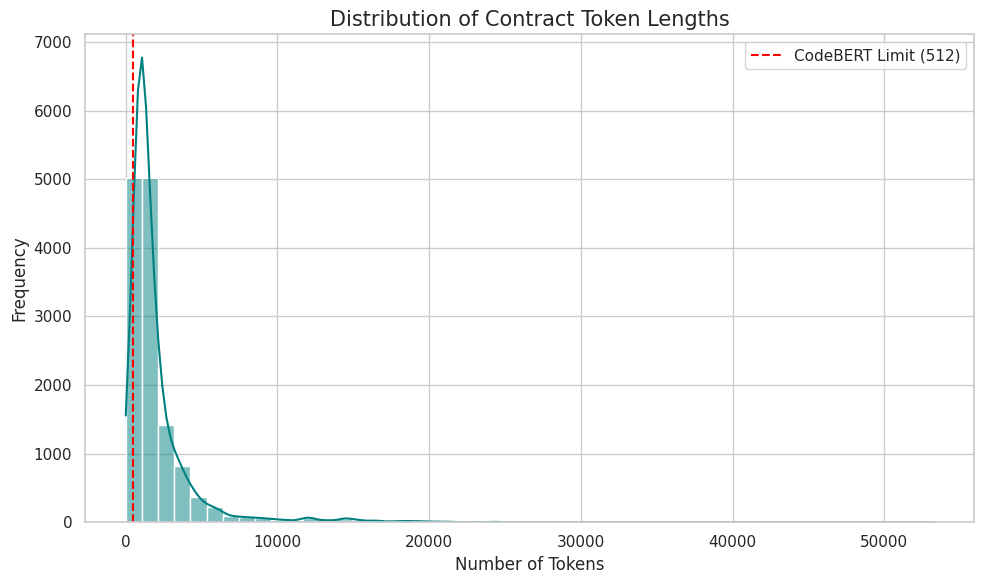

In [86]:
plt.figure(figsize=(10, 6))

# Plot histogram of the token_len column you already created
sns.histplot(df_clean['token_len'], bins=50, kde=True, color='teal')

# Draw a vertical line at the 512 mark
plt.axvline(x=512, color='red', linestyle='--', label='CodeBERT Limit (512)')

plt.title('Distribution of Contract Token Lengths', fontsize=15)
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

# Annotate the percentage of data over the limit
over_limit = (df_clean['token_len'] > 512).mean() * 100
print(over_limit)

plt.tight_layout()
plt.savefig('token_length_dist.png', dpi=300)
plt.show()

Split data


In [87]:
# splitting:
from sklearn.model_selection import train_test_split
seed = 32
temp_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    stratify=df_clean['is_vulnerable'],
    random_state=seed
)


train_df, val_df = train_test_split(
    temp_df,
    test_size=0.25,
    stratify=temp_df['is_vulnerable'],
    random_state=seed
)

In [88]:
train_vulnerable = train_df[train_df['is_vulnerable'] == True]
train_safe = train_df[train_df['is_vulnerable'] == False]

def custom_sample(group):
  # ignore minority class:
  if len(group) <= 500:
      return group

  frac = min(1.0, 3000 / len(group))
  return group.sample(frac=frac, random_state=seed)

# resample to balance
train_vulnerable_sampled = train_vulnerable.groupby('labels').apply(custom_sample).reset_index(drop=True)

# recombine
train_df_final = pd.concat([train_vulnerable_sampled, train_safe]).sample(frac=1, random_state=seed)

/tmp/ipykernel_16490/2465420474.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_vulnerable_sampled = train_vulnerable.groupby('labels').apply(custom_sample).reset_index(drop=True)


In [89]:
train_df_final["labels"].value_counts()
train_df["labels"].value_counts()

,count
labels,
arithmetic,4298
clean,1613
reentrancy,837
front_running,504
denial_service,465
unchecked_low_calls,179
access_control,99
time_manipulation,55


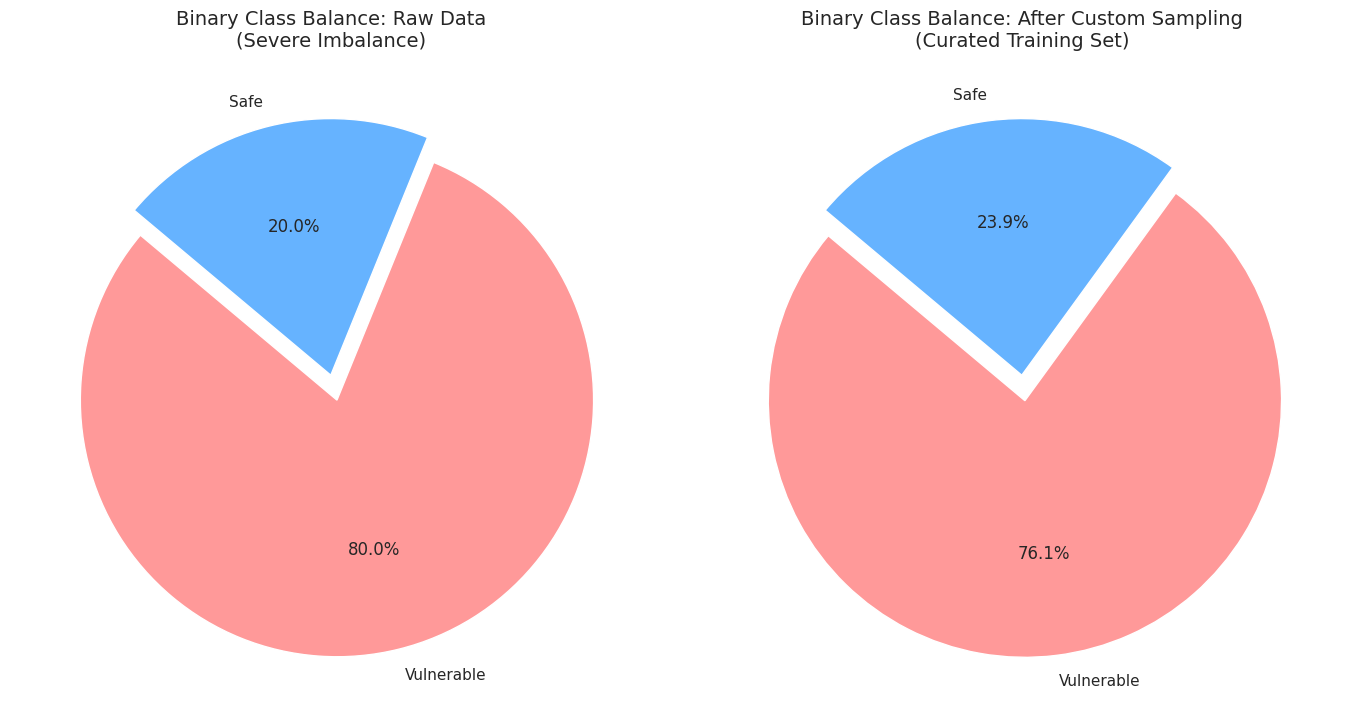

In [90]:
# show pie chart of the difference in distribution of samples before and after sampling
before_counts = df_clean['is_vulnerable'].value_counts()
after_counts = train_df_final['is_vulnerable'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Red == Vulnerable, Green == Safe
colors = ['#ff9999','#66b3ff']
labels = ['Vulnerable', 'Safe']

# Before
ax1.pie(before_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
ax1.set_title('Binary Class Balance: Raw Data\n(Severe Imbalance)', fontsize=14)

# After
ax2.pie(after_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
ax2.set_title('Binary Class Balance: After Custom Sampling\n(Curated Training Set)', fontsize=14)

plt.tight_layout()
plt.savefig('imbalance_comparison.png', dpi=300)
plt.show()

In [91]:
print(f"Training: {train_df_final.shape}\n{train_df['is_vulnerable'].value_counts()}")
print(f"Validation: {val_df.shape}\n{val_df['is_vulnerable'].value_counts()}")
print(f"Test: {test_df.shape}\n{test_df['is_vulnerable'].value_counts()}")

Training: (6752, 10)
is_vulnerable
True     6437
False    1613
Name: count, dtype: int64
Validation: (2684, 10)
is_vulnerable
True     2146
False     538
Name: count, dtype: int64
Test: (2684, 10)
is_vulnerable
True     2146
False     538
Name: count, dtype: int64


# Contract Processing into Chunks:

In [92]:
import ast
import random
# helper function for sampling smart contract chunks
def smart_sample_contract(chunks, vuln_indices, max_chunks=10, context_size=1):
    """
    Ensures at least one vulnerable chunk + neighboring context chunks are included.
    """

    if len(chunks) <= max_chunks:
        return chunks

    selected_indices = set()

    # pick vulnerable chunk
    if len(vuln_indices) > 0:
        chosen_vuln = random.choice(vuln_indices)
        selected_indices.add(chosen_vuln)

        # add neighbours for local context
        for offset in range(1, context_size + 1):
            if chosen_vuln - offset >= 0:
                selected_indices.add(chosen_vuln - offset)
            if chosen_vuln + offset < len(chunks):
                selected_indices.add(chosen_vuln + offset)

    # fill in remaining
    remaining_pool = [i for i in range(len(chunks)) if i not in selected_indices]
    num_to_fill = max_chunks - len(selected_indices)

    if num_to_fill > 0:
        selected_indices.update(random.sample(
            remaining_pool,
            min(num_to_fill, len(remaining_pool))
        ))

    # maintain ordering of chunks
    selected_indices = sorted(selected_indices)

    # trim if exceeding max
    if len(selected_indices) > max_chunks:
      selected_indices = selected_indices[:max_chunks]
    # ensures vuln included
    if len(vuln_indices) > 0 and not any(i in selected_indices for i in vuln_indices):
      selected_indices[-1] = random.choice(vuln_indices)

    return [chunks[i] for i in selected_indices]

In [93]:
MAX_TOKENS = 512
STRIDE = MAX_TOKENS // 2

# helper function for chunking while keeping track of line numbers:
def chunk_with_line_tracking(text, tokenizer, max_tokens=512, stride=256):
    lines = text.split('\n')

    line_token_ids = []
    for line in lines:
        tokens = tokenizer.encode(line, add_special_tokens=False)
        line_token_ids.append(tokens)

    chunks = []
    current_tokens = []
    current_lines = []

    for line_idx, tokens in enumerate(line_token_ids):
        if len(tokens) == 0:
            continue

        if len(current_tokens) + len(tokens) > max_tokens:
            chunks.append({
                "input_ids": current_tokens,
                "attention_mask": [1] * len(current_tokens),
                "line_indices": current_lines.copy()
            })

            # stride: keep overlaps
            overlap_tokens = current_tokens[-stride:] if stride < len(current_tokens) else current_tokens
            overlap_lines = current_lines[-len(overlap_tokens):]

            current_tokens = overlap_tokens.copy()
            current_lines = overlap_lines.copy()

        current_tokens.extend(tokens)
        current_lines.extend([line_idx] * len(tokens))

    # last chunk
    if current_tokens:
        chunks.append({
            "input_ids": current_tokens,
            "attention_mask": [1] * len(current_tokens),
            "line_indices": current_lines
        })

    return chunks

# helper for getting the vulnerable indices
def get_vulnerable_indices(chunks, vuln_lines):
    vuln_indices = []

    vuln_set = set(vuln_lines)

    for i, chunk in enumerate(chunks):
        if any(line in vuln_set for line in chunk["line_indices"]):
            vuln_indices.append(i)

    return vuln_indices

# helper for padding the rest of the space in the chunks
def pad_chunk(chunk, max_len=512):
    input_ids = chunk["input_ids"]
    attention_mask = chunk["attention_mask"]
    line_indices = chunk.get("line_indices", [])

    pad_id = tokenizer.pad_token_id

    padding_length = max_len - len(input_ids)

    if padding_length < 0:
        input_ids = input_ids[:max_len]
        attention_mask = attention_mask[:max_len]
        line_indices = line_indices[:max_len]
        padding_length = 0

    return {
        "input_ids": input_ids + [pad_id] * padding_length,
        "attention_mask": attention_mask + [0] * padding_length,
        "line_indices": line_indices + [-1] * padding_length  # -1 = padding
    }

In [94]:
# process data
def process_data(df, max_chunks=10, is_training=True):
    processed_data = []

    for _, row in df.iterrows():
        source = str(row['cleaned_contract'])

        # get vulnerable lines:
        raw_lines = row['lines']
        if isinstance(raw_lines, str):
            try:
                raw_list = ast.literal_eval(raw_lines)
                if isinstance(raw_list, list) and len(raw_list) > 0 and isinstance(raw_list[0], list):
                    vuln_lines = list(set(
                        item for sublist in raw_list for item in sublist
                    ))
                else:
                    vuln_lines = list(set(raw_list))
            except:
                vuln_lines = []
        else:
            vuln_lines = raw_lines if isinstance(raw_lines, list) else []

        # chunk
        chunks = chunk_with_line_tracking(source, tokenizer)
        if is_training:
            vuln_indices = get_vulnerable_indices(chunks, vuln_lines)
            final_chunks = smart_sample_contract(chunks, vuln_indices, max_chunks)
        else:
            final_chunks = chunks

        chunk_labels = []
        vuln_set = set(vuln_lines)
        for chunk in final_chunks:
            if any(line in vuln_set for line in chunk["line_indices"]):
                chunk_labels.append(1)
            else:
                chunk_labels.append(0)

        final_chunks = [pad_chunk(c) for c in final_chunks]
        processed_data.append({
          "contract_id": row["contract_id"],
          "chunks": final_chunks,
          "chunk_labels": chunk_labels,
          "label": int(row["is_vulnerable"])
        })

    return processed_data

# split to train, validation and test:
train_chunks_list = process_data(train_df_final, is_training=True)
val_chunks_list = process_data(val_df, is_training=False)
test_chunks_list = process_data(test_df, is_training=False)

In [95]:
train_chunks_list[0]["chunk_labels"]

[1, 1]

In [96]:
import torch
TARGET_DIR = '/content/drive/My Drive/CPSC440_project/data/'
torch.save(train_chunks_list, TARGET_DIR+"train_chunks.pt")
torch.save(val_chunks_list, TARGET_DIR+"val_chunks.pt")
torch.save(test_chunks_list, TARGET_DIR+"test_chunks.pt")